Using optimal feature set: 10 features
Features: ['Fast food (Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)', 'Cycle(R/I)', 'Cycle length(days)', 'Weight gain(Y/N)', 'AMH(ng/mL)', ' Age (yrs)', '  I   beta-HCG(mIU/mL)', 'FSH(mIU/mL)']

PART 1: CALIBRATION ANALYSIS

Model                           Brier Score      AUC
-------------------------------------------------------
RF (uncalibrated)                   0.02166   0.9968
RF + Platt Scaling                  0.02246   0.9944
RF + Isotonic Regression            0.02159   0.9944 ← lowest (best)

Note: Brier Score = mean squared error of probability predictions
      Lower is better. Perfect = 0.000, Random = ~0.210


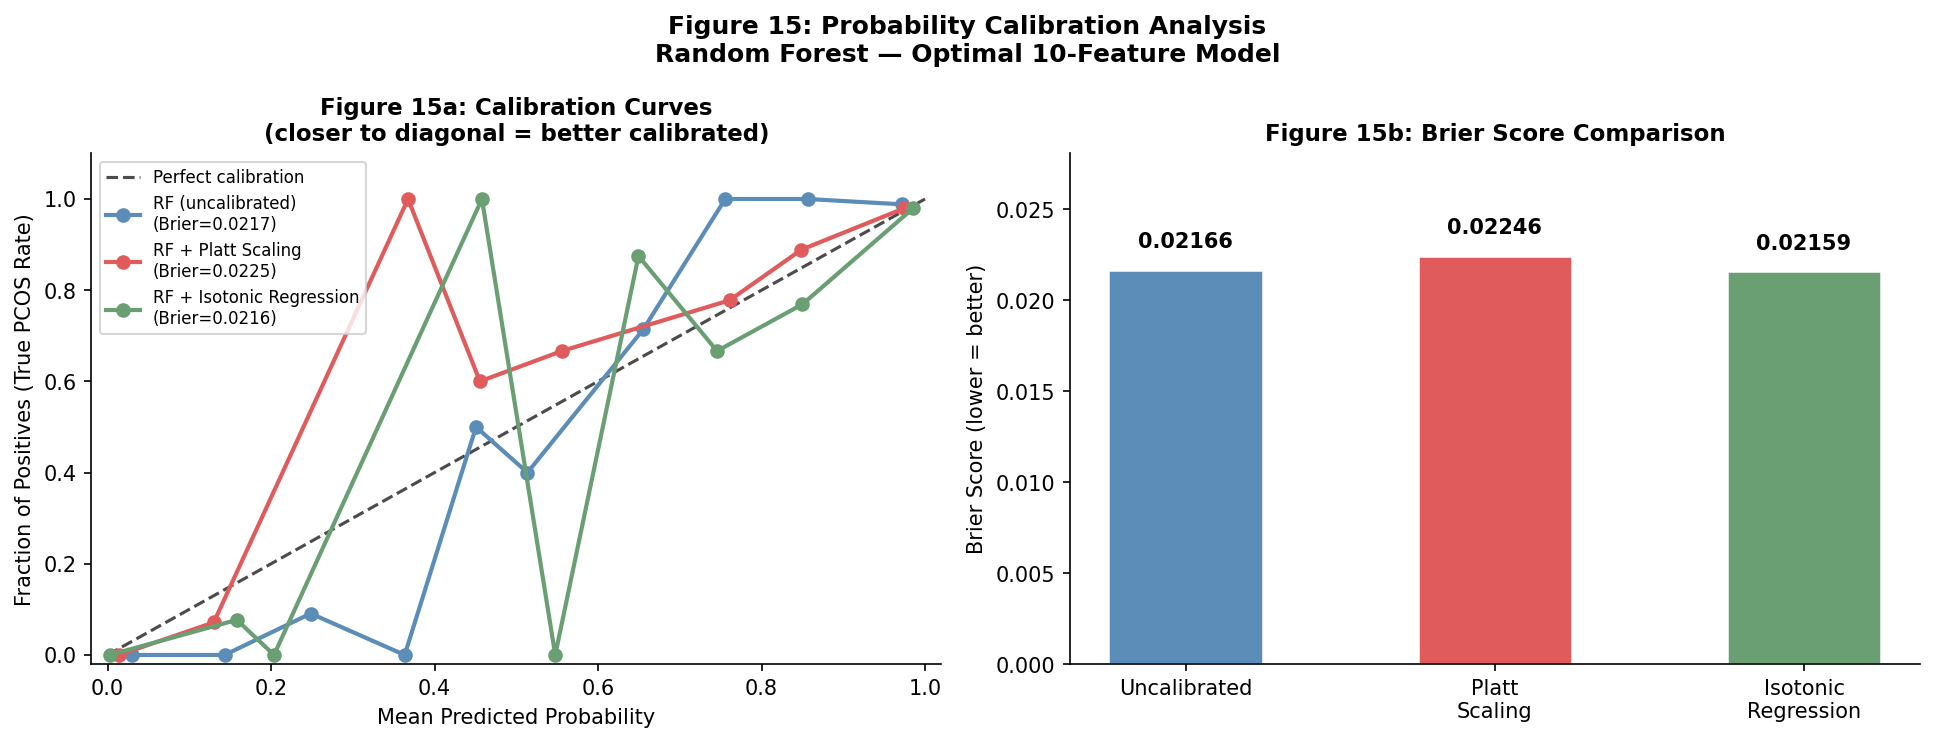


✓ Figure 15 saved


PART 2: THRESHOLD OPTIMISATION

Using: RF + Isotonic Regression

Scenario                        Threshold  Sensitivity  Specificity      PPV      NPV       F1
--------------------------------------------------------------------------------------------
Default (0.5)                        0.50       0.9832       0.9675   0.9286   0.9926   0.9551
Screening (sens≥0.95)                0.64       0.9832       0.9783   0.9512   0.9927   0.9669
Balanced (max F1)                    0.64       0.9832       0.9783   0.9512   0.9927   0.9669

PPV = Positive Predictive Value (precision)
NPV = Negative Predictive Value
Prevalence in test set: 0.301 (30% PCOS)


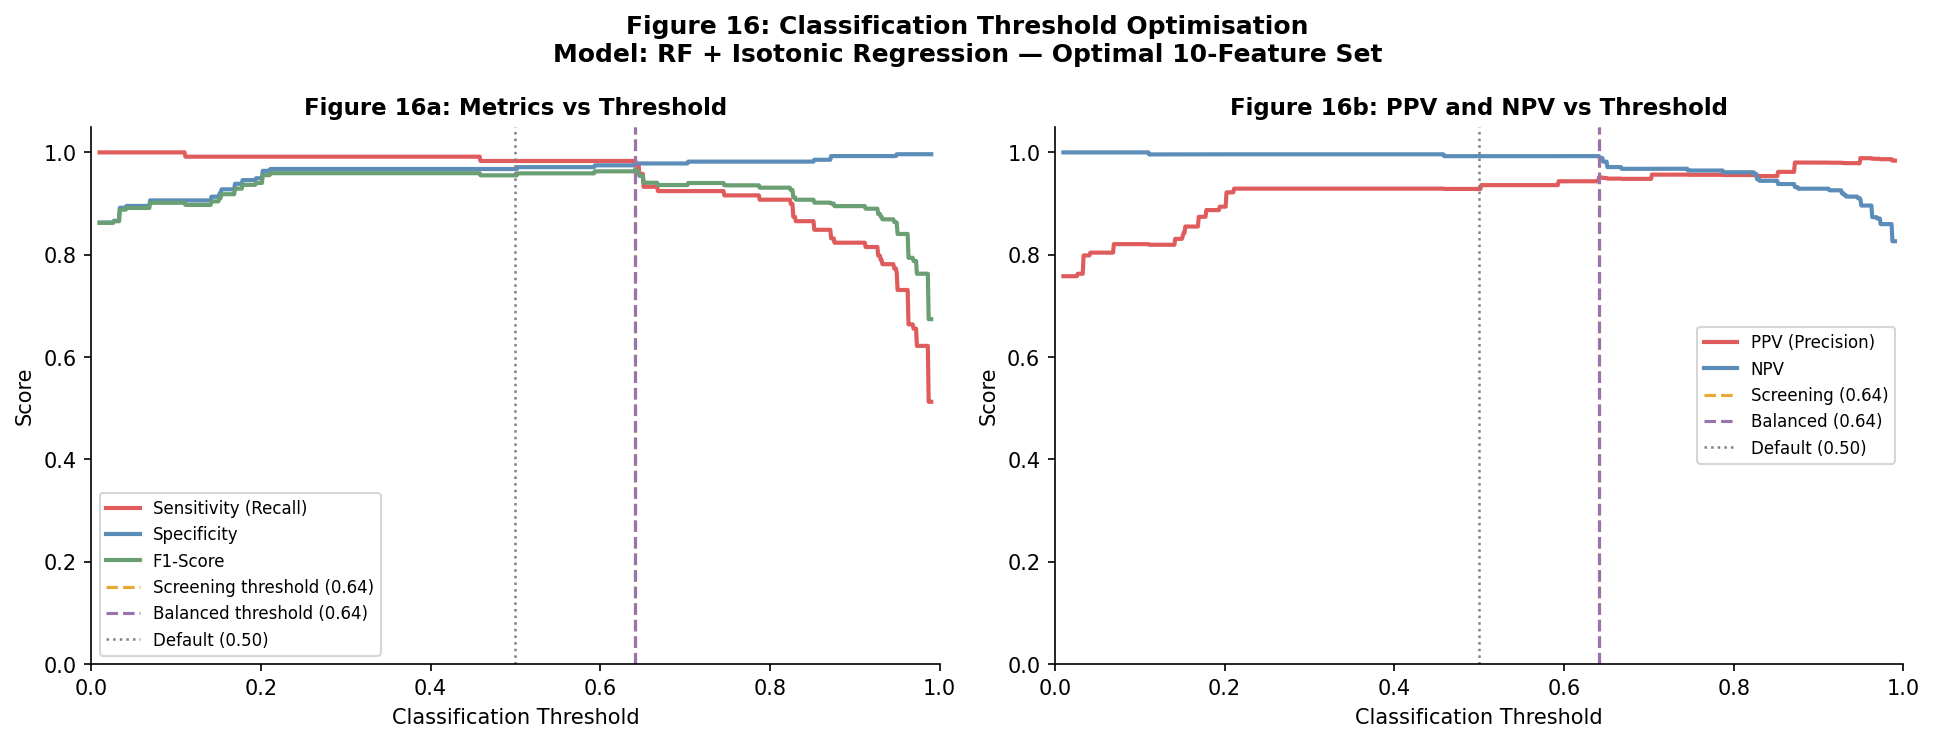


✓ Figure 16 saved

✓ Calibration and threshold results saved
✓ Best calibrated model saved for web app
✓ Ready for Step 9: Paper Figures + Tables Consolidation


In [ ]:
# ============================================================
# STEP 8: CALIBRATION + THRESHOLD ANALYSIS
# PCOS Classification Project
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (roc_auc_score, brier_score_loss,
                             f1_score, recall_score,
                             precision_score, confusion_matrix)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# ── Load data ─────────────────────────────────────────────────
df     = pd.read_csv('PCOS_clean.csv')
target = 'PCOS (Y/N)'
X      = df.drop(columns=[target])
y      = df[target]

with open('step7_reduction.pkl', 'rb') as f:
    step7 = pickle.load(f)

optimal_features = step7['optimal_res']['features']
print(f"Using optimal feature set: {len(optimal_features)} features")
print(f"Features: {optimal_features}\n")

X_opt = X[optimal_features]

# ── Train/test split ──────────────────────────────────────────
X_tr, X_te, y_tr, y_te = train_test_split(
    X_opt, y, test_size=0.2,
    random_state=42, stratify=y
)

# Apply SMOTE + scaling
smote    = SMOTE(random_state=42, k_neighbors=5)
X_tr_res, y_tr_res = smote.fit_resample(X_tr, y_tr)

scaler   = StandardScaler()
X_tr_sc  = scaler.fit_transform(X_tr_res)
X_te_sc  = scaler.transform(X_te)

# ════════════════════════════════════════════════════════════
# PART 1: CALIBRATION ANALYSIS
#
# We compare three versions of RF:
#   A) Uncalibrated RF
#   B) RF + Platt Scaling (sigmoid calibration)
#   C) RF + Isotonic Regression calibration
#
# Brier Score: lower is better (0 = perfect, 0.25 = random)
# ════════════════════════════════════════════════════════════
print("=" * 60)
print("PART 1: CALIBRATION ANALYSIS")
print("=" * 60)

rf_base = RandomForestClassifier(
    n_estimators=200, min_samples_split=5,
    min_samples_leaf=2, class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf_base.fit(X_tr_sc, y_tr_res)

# Calibrated versions — fit on original (non-SMOTE) training data
# Calibration must be fit on held-out data to avoid overfitting
X_tr_orig_sc = scaler.transform(X_tr)   # original, unbalanced

rf_platt = CalibratedClassifierCV(
    RandomForestClassifier(
        n_estimators=200, min_samples_split=5,
        min_samples_leaf=2, class_weight='balanced',
        random_state=42, n_jobs=-1),
    method='sigmoid', cv=5
)
rf_platt.fit(X_tr_orig_sc, y_tr)

rf_isotonic = CalibratedClassifierCV(
    RandomForestClassifier(
        n_estimators=200, min_samples_split=5,
        min_samples_leaf=2, class_weight='balanced',
        random_state=42, n_jobs=-1),
    method='isotonic', cv=5
)
rf_isotonic.fit(X_tr_orig_sc, y_tr)

models_cal = {
    'RF (uncalibrated)':       rf_base,
    'RF + Platt Scaling':      rf_platt,
    'RF + Isotonic Regression':rf_isotonic,
}

print(f"\n{'Model':<30} {'Brier Score':>12} {'AUC':>8}")
print("-" * 55)

calibration_data = {}
for name, model in models_cal.items():
    probs  = model.predict_proba(X_te_sc)[:, 1]
    brier  = brier_score_loss(y_te, probs)
    auc    = roc_auc_score(y_te, probs)
    frac_pos, mean_pred = calibration_curve(
        y_te, probs, n_bins=10, strategy='uniform'
    )
    calibration_data[name] = {
        'probs': probs, 'brier': brier,
        'auc': auc, 'frac_pos': frac_pos,
        'mean_pred': mean_pred
    }
    flag = " ← lowest (best)" if name == min(
        models_cal, key=lambda n:
        brier_score_loss(y_te,
            models_cal[n].predict_proba(X_te_sc)[:,1])
    ) else ""
    print(f"{name:<30} {brier:>12.5f} {auc:>8.4f}{flag}")

print("\nNote: Brier Score = mean squared error of probability predictions")
print("      Lower is better. Perfect = 0.000, Random = ~0.210")

# ════════════════════════════════════════════════════════════
# FIGURE 15 — Calibration Curves
# ════════════════════════════════════════════════════════════
plt.rcParams.update({
    'font.size': 10, 'axes.titlesize': 11,
    'axes.titleweight': 'bold',
    'axes.spines.top': False, 'axes.spines.right': False,
    'figure.dpi': 150, 'savefig.dpi': 300,
    'savefig.bbox': 'tight'
})

cal_colors = {
    'RF (uncalibrated)':        '#5B8DB8',
    'RF + Platt Scaling':       '#E05C5C',
    'RF + Isotonic Regression': '#6A9E73',
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Calibration curves
ax1.plot([0, 1], [0, 1], 'k--', linewidth=1.5,
         label='Perfect calibration', alpha=0.7)

for name, data in calibration_data.items():
    ax1.plot(data['mean_pred'], data['frac_pos'],
             'o-', color=cal_colors[name], linewidth=2,
             markersize=6,
             label=f"{name}\n(Brier={data['brier']:.4f})")

ax1.set_xlabel('Mean Predicted Probability')
ax1.set_ylabel('Fraction of Positives (True PCOS Rate)')
ax1.set_title('Figure 15a: Calibration Curves\n'
              '(closer to diagonal = better calibrated)')
ax1.legend(fontsize=8, loc='upper left')
ax1.set_xlim([-0.02, 1.02])
ax1.set_ylim([-0.02, 1.10])

# Brier score bar chart
names_short = ['Uncalibrated', 'Platt\nScaling',
               'Isotonic\nRegression']
briers = [calibration_data[n]['brier']
          for n in models_cal.keys()]
colors_b = list(cal_colors.values())

bars = ax2.bar(names_short, briers, color=colors_b,
               edgecolor='white', linewidth=1.2, width=0.5)
ax2.set_ylabel('Brier Score (lower = better)')
ax2.set_title('Figure 15b: Brier Score Comparison')
ax2.set_ylim(0, max(briers) * 1.25)

for bar, val in zip(bars, briers):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.001,
             f'{val:.5f}', ha='center',
             va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Figure 15: Probability Calibration Analysis\n'
             'Random Forest — Optimal 10-Feature Model',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig15_calibration.png')
plt.show()
print("\n✓ Figure 15 saved")

# ════════════════════════════════════════════════════════════
# PART 2: THRESHOLD OPTIMISATION
#
# Find the best classification threshold under two clinical
# scenarios:
#   Scenario A — Screening: maximise sensitivity (catch all PCOS)
#                Constraint: sensitivity ≥ 0.95
#   Scenario B — Confirmation: maximise F1 (balanced performance)
#
# Use the best-calibrated model's probabilities
# ════════════════════════════════════════════════════════════
print("\n\n" + "=" * 60)
print("PART 2: THRESHOLD OPTIMISATION")
print("=" * 60)

# Use best calibrated model
best_cal_name  = min(calibration_data,
                     key=lambda n: calibration_data[n]['brier'])
best_probs     = calibration_data[best_cal_name]['probs']
print(f"\nUsing: {best_cal_name}")

thresholds = np.linspace(0.01, 0.99, 990)

sensitivities  = []
specificities  = []
f1_scores      = []
precisions     = []
ppvs           = []
npvs           = []

prevalence = y_te.mean()

for thresh in thresholds:
    preds = (best_probs >= thresh).astype(int)
    cm    = confusion_matrix(y_te, preds,
                             labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1   = (2 * prec * sens / (prec + sens)
            if (prec + sens) > 0 else 0)
    ppv  = prec
    npv  = tn / (tn + fn) if (tn + fn) > 0 else 0

    sensitivities.append(sens)
    specificities.append(spec)
    f1_scores.append(f1)
    precisions.append(prec)
    ppvs.append(ppv)
    npvs.append(npv)

sensitivities = np.array(sensitivities)
specificities = np.array(specificities)
f1_scores     = np.array(f1_scores)
ppvs          = np.array(ppvs)
npvs          = np.array(npvs)

# ── Scenario A: Screening threshold ───────────────────────────
# Highest specificity where sensitivity ≥ 0.95
screen_mask = sensitivities >= 0.95
if screen_mask.any():
    screen_idx   = np.where(screen_mask)[0][
        np.argmax(specificities[screen_mask])
    ]
    screen_thresh = thresholds[screen_idx]
    screen_sens   = sensitivities[screen_idx]
    screen_spec   = specificities[screen_idx]
    screen_ppv    = ppvs[screen_idx]
    screen_npv    = npvs[screen_idx]
    screen_f1     = f1_scores[screen_idx]
else:
    screen_idx    = np.argmax(sensitivities)
    screen_thresh = thresholds[screen_idx]
    screen_sens   = sensitivities[screen_idx]
    screen_spec   = specificities[screen_idx]
    screen_ppv    = ppvs[screen_idx]
    screen_npv    = npvs[screen_idx]
    screen_f1     = f1_scores[screen_idx]

# ── Scenario B: Balanced threshold (max F1) ───────────────────
f1_idx        = np.argmax(f1_scores)
f1_thresh     = thresholds[f1_idx]
f1_sens       = sensitivities[f1_idx]
f1_spec       = specificities[f1_idx]
f1_ppv        = ppvs[f1_idx]
f1_npv        = npvs[f1_idx]
f1_val        = f1_scores[f1_idx]

# ── Scenario C: Default threshold (0.5) ───────────────────────
default_idx   = np.argmin(np.abs(thresholds - 0.5))
default_sens  = sensitivities[default_idx]
default_spec  = specificities[default_idx]
default_ppv   = ppvs[default_idx]
default_npv   = npvs[default_idx]
default_f1    = f1_scores[default_idx]

print(f"\n{'Scenario':<30} {'Threshold':>10} {'Sensitivity':>12} "
      f"{'Specificity':>12} {'PPV':>8} {'NPV':>8} {'F1':>8}")
print("-" * 92)
print(f"{'Default (0.5)':<30} {0.50:>10.2f} "
      f"{default_sens:>12.4f} {default_spec:>12.4f} "
      f"{default_ppv:>8.4f} {default_npv:>8.4f} {default_f1:>8.4f}")
print(f"{'Screening (sens≥0.95)':<30} {screen_thresh:>10.2f} "
      f"{screen_sens:>12.4f} {screen_spec:>12.4f} "
      f"{screen_ppv:>8.4f} {screen_npv:>8.4f} {screen_f1:>8.4f}")
print(f"{'Balanced (max F1)':<30} {f1_thresh:>10.2f} "
      f"{f1_sens:>12.4f} {f1_spec:>12.4f} "
      f"{f1_ppv:>8.4f} {f1_npv:>8.4f} {f1_val:>8.4f}")
print("=" * 92)
print("\nPPV = Positive Predictive Value (precision)")
print("NPV = Negative Predictive Value")
print(f"Prevalence in test set: {prevalence:.3f} (30% PCOS)")

# ════════════════════════════════════════════════════════════
# FIGURE 16 — Threshold Analysis Plot
# ════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Sensitivity, Specificity, F1 vs Threshold
ax = axes[0]
ax.plot(thresholds, sensitivities,
        color='#E05C5C', linewidth=2, label='Sensitivity (Recall)')
ax.plot(thresholds, specificities,
        color='#5B8DB8', linewidth=2, label='Specificity')
ax.plot(thresholds, f1_scores,
        color='#6A9E73', linewidth=2, label='F1-Score')

ax.axvline(screen_thresh, color='#E8A838',
           linestyle='--', linewidth=1.5,
           label=f'Screening threshold ({screen_thresh:.2f})')
ax.axvline(f1_thresh, color='#9B72B0',
           linestyle='--', linewidth=1.5,
           label=f'Balanced threshold ({f1_thresh:.2f})')
ax.axvline(0.5, color='gray',
           linestyle=':', linewidth=1.2,
           label='Default (0.50)')

ax.set_xlabel('Classification Threshold')
ax.set_ylabel('Score')
ax.set_title('Figure 16a: Metrics vs Threshold')
ax.legend(fontsize=8, loc='lower left')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])

# Right: PPV and NPV vs Threshold
ax2 = axes[1]
ax2.plot(thresholds, ppvs,
         color='#E05C5C', linewidth=2,
         label='PPV (Precision)')
ax2.plot(thresholds, npvs,
         color='#5B8DB8', linewidth=2, label='NPV')

ax2.axvline(screen_thresh, color='#E8A838',
            linestyle='--', linewidth=1.5,
            label=f'Screening ({screen_thresh:.2f})')
ax2.axvline(f1_thresh, color='#9B72B0',
            linestyle='--', linewidth=1.5,
            label=f'Balanced ({f1_thresh:.2f})')
ax2.axvline(0.5, color='gray',
            linestyle=':', linewidth=1.2,
            label='Default (0.50)')

ax2.set_xlabel('Classification Threshold')
ax2.set_ylabel('Score')
ax2.set_title('Figure 16b: PPV and NPV vs Threshold')
ax2.legend(fontsize=8, loc='center right')
ax2.set_xlim([0, 1])
ax2.set_ylim([0, 1.05])

plt.suptitle('Figure 16: Classification Threshold Optimisation\n'
             f'Model: {best_cal_name} — Optimal 10-Feature Set',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig16_threshold.png')
plt.show()
print("\n✓ Figure 16 saved")

# ════════════════════════════════════════════════════════════
# SAVE
# ════════════════════════════════════════════════════════════
with open('step8_calibration.pkl', 'wb') as f:
    pickle.dump({
        'calibration_data':  calibration_data,
        'best_cal_name':     best_cal_name,
        'best_probs':        best_probs,
        'best_model':        models_cal[best_cal_name],
        'scaler':            scaler,
        'optimal_features':  optimal_features,
        'threshold_screening': float(screen_thresh),
        'threshold_balanced':  float(f1_thresh),
        'threshold_results': {
            'default':   {'thresh': 0.50, 'sens': default_sens,
                          'spec': default_spec, 'ppv': default_ppv,
                          'npv': default_npv, 'f1': default_f1},
            'screening': {'thresh': float(screen_thresh),
                          'sens': screen_sens, 'spec': screen_spec,
                          'ppv': screen_ppv, 'npv': screen_npv,
                          'f1': screen_f1},
            'balanced':  {'thresh': float(f1_thresh),
                          'sens': f1_sens, 'spec': f1_spec,
                          'ppv': f1_ppv, 'npv': f1_npv,
                          'f1': f1_val},
        },
        'y_test': y_te,
        'X_test': X_te,
    }, f)

print("\n✓ Calibration and threshold results saved")
print("✓ Best calibrated model saved for web app")
print("✓ Ready for Step 9: Paper Figures + Tables Consolidation")